In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
folder = Path('california')

months = [f"2024{m:02d}" for m in range(1, 7)]   # 2024-01 to 2024-06

files = []
for m in months:
    matches = list(folder.glob(f"CRMLSSold{m}*.csv"))
    if not matches:
        print(f"Missing: {m}")
    files.extend(matches)

print(len(files), "files found")

df = pd.concat(
    (pd.read_csv(f, low_memory=False).assign(source_file=f.name) for f in files),
    ignore_index=True,
)
print(df.shape)

6 files found
(136614, 83)


In [9]:
df.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [10]:
df_filtered = df[(df['PropertyType'] =='Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
df_filtered.shape

(68641, 83)

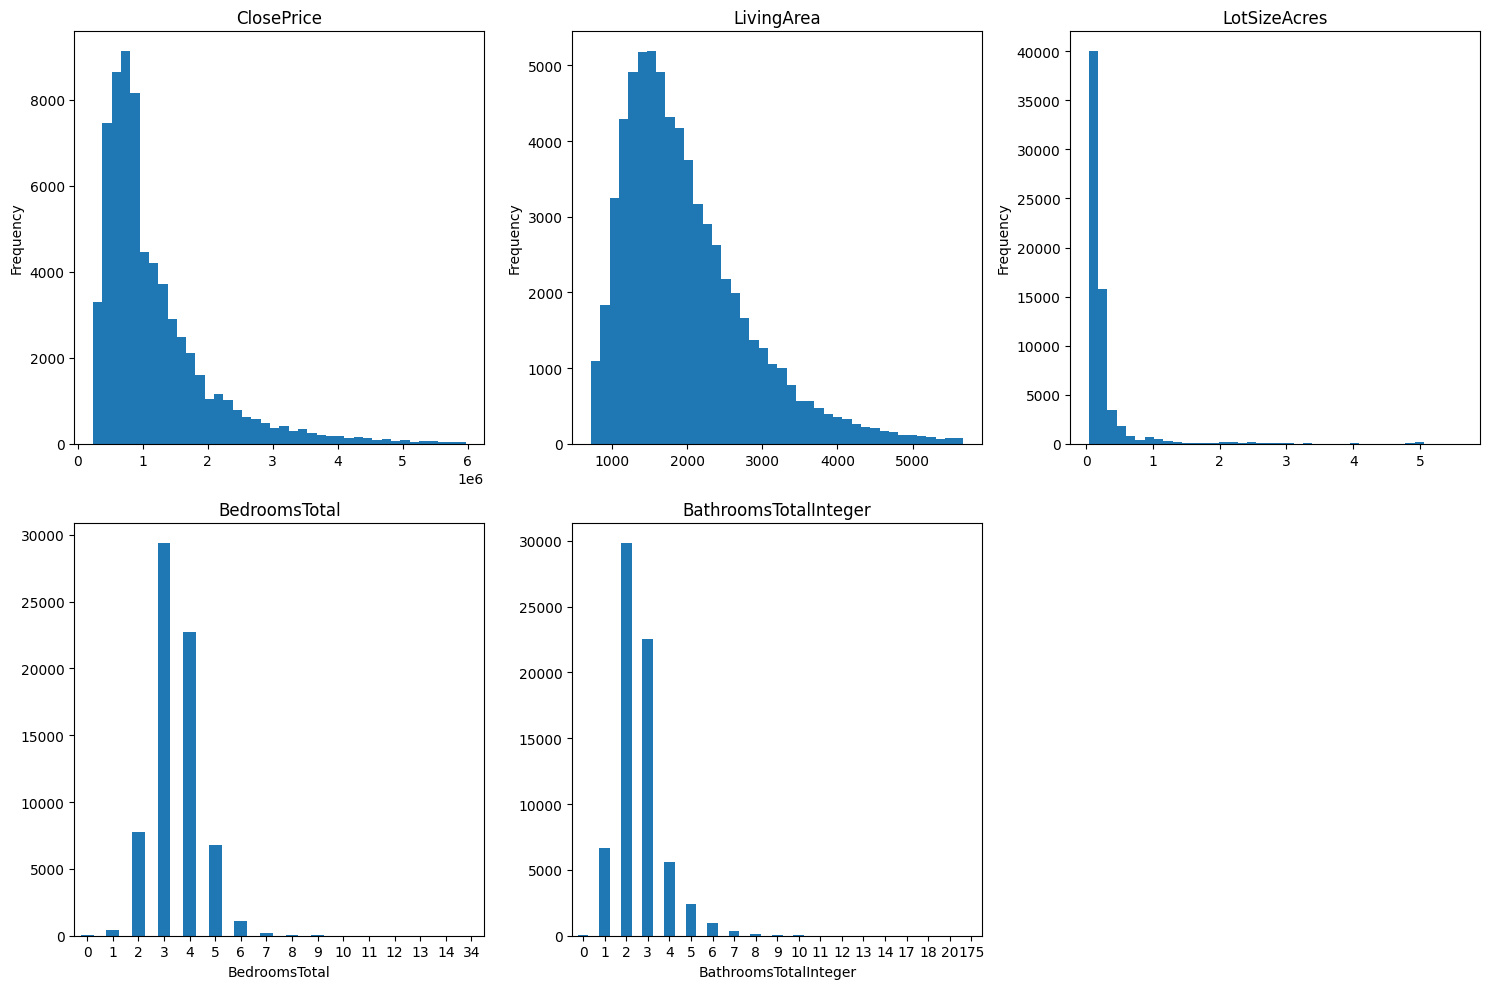

In [37]:
fig, axes = plt.subplots(figsize=(15, 10), nrows=2, ncols=3)
hist_cols = ['ClosePrice', 'LivingArea', 'LotSizeAcres']
int_cols = ['BedroomsTotal', 'BathroomsTotalInteger']

for ax, prop in zip(axes.flat, hist_cols):
    s = df_filtered[prop].dropna()
    lo, hi = s.quantile([0.01, 0.99])
    s[(s >= lo) & (s <= hi)].plot(kind='hist', bins=40, ax=ax, title=prop)

for ax, prop in zip(axes.flat[len(hist_cols):], int_cols):
    counts = (df_filtered[prop].dropna().astype(int)
              .value_counts().sort_index())
    counts.plot(kind='bar', ax=ax, title=prop)
    ax.tick_params(axis='x', rotation=0)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

In [47]:
properties = hist_cols + int_cols

for prop in properties:
    summary = df_filtered[prop].describe().T
    summary['nulls'] = df_filtered[prop].isna().sum()
    summary['skew'] = df_filtered[prop].skew()
    print(str(summary) + '\n----------------------------------------------')
    

count    6.864000e+04
mean     1.257151e+06
std      1.330793e+06
min      3.450000e+02
25%      6.150000e+05
50%      8.950000e+05
75%      1.460000e+06
max      6.280000e+07
nulls    1.000000e+00
skew     8.632369e+00
Name: ClosePrice, dtype: float64
----------------------------------------------
count    68605.000000
mean      2027.036120
std       1027.672641
min          0.000000
25%       1367.000000
50%       1798.000000
75%       2414.000000
max      22897.000000
nulls       36.000000
skew         2.987381
Name: LivingArea, dtype: float64
----------------------------------------------
count    6.747500e+04
mean     1.205122e+02
std      3.007063e+04
min      0.000000e+00
25%      1.300000e-01
50%      1.657000e-01
75%      2.354000e-01
max      7.810698e+06
nulls    1.166000e+03
skew     2.597161e+02
Name: LotSizeAcres, dtype: float64
----------------------------------------------
count    68641.000000
mean         3.471497
std          0.952916
min          0.000000
25%       